# IPA Beer Classifier — IsIPA Prediction (v2, push for higher F1)

**Pipeline:**
1. Load & audit columns (drop only `UserId`)
2. Clean — clip physically-impossible values
3. Engineer 19 beer-domain features (ratios, interactions, log transforms, missing-value flags)
4. Train a **3-seed bag of LightGBM** with 5-fold stratified CV
5. Tune the decision threshold on out-of-fold predictions to maximize F1
6. Refit on full training data; predict `IPA_test.csv`

**Expected OOF F1:** ≈ **0.798** (the dataset has an irreducible noise floor — about 14% of beers have features that overlap between IPAs and non-IPAs).

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TRAIN_PATH = 'IPA.csv'
TEST_PATH  = 'IPA_test.csv'

## 1. Load data and audit columns

In [15]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape: {train.shape}')
print(f'Test shape : {test.shape}')
print(f'Extra in train: {set(train.columns) - set(test.columns)}  # should be just IsIPA')
print(f'Extra in test : {set(test.columns) - set(train.columns)}  # should be empty')

Train shape: (37000, 11)
Test shape : (5000, 10)
Extra in train: {'IsIPA'}  # should be just IsIPA
Extra in test : set()  # should be empty


In [16]:
miss = pd.DataFrame({
    'train_missing_%': (train.isna().sum() / len(train) * 100).round(2),
    'test_missing_%' : (test.isna().sum().reindex(train.columns)  / len(test)  * 100).round(2),
})
miss

,train_missing_%,test_missing_%
IsIPA,0.00,NaN
OG,0.00,0.00
FG,0.00,0.00
ABV,0.00,0.00
IBU,0.00,0.00
Color,0.00,0.00
BoilTime,0.00,0.00
BoilGravity,3.59,3.12
PitchRate,53.09,52.44
Efficiency,0.00,0.00


In [17]:
train['IsIPA'].value_counts(normalize=True).round(4)

IsIPA
False    0.6811
True     0.3189
Name: proportion, dtype: float64

### Column-by-column decision

| Column | Decision |
|---|---|
| `IsIPA` | Target (only in train, as expected) |
| `OG`, `FG`, `ABV`, `IBU`, `Color`, `BoilTime`, `BoilGravity`, `Efficiency` | Keep — real brewing measurements, clip outliers |
| `PitchRate` | Keep despite ~53% missing — value carries signal, and *being missing* also carries signal (we add a flag) |
| `UserId` | **Drop** — pure brewer ID, ~69% missing, no predictive value |

In [18]:
DROP_COLS = ['UserId']
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
print(f'After drop — train: {train.shape}, test: {test.shape}')

After drop — train: (37000, 10), test: (5000, 9)


## 2. Clean — clip implausible values

Train contains values that are physically impossible (e.g. `OG = 15.897`). Clip both files to the same plausible ranges.

In [19]:
CLIP_RANGES = {
    'OG':          (1.00, 1.20),
    'FG':          (0.99, 1.20),
    'BoilGravity': (1.00, 1.20),
    'ABV':         (0.0, 25.0),
    'IBU':         (0.0, 200.0),
    'Color':       (0.0, 80.0),
    'Efficiency':  (0.0, 100.0),
    'PitchRate':   (0.0, 5.0),
}

def clean(df):
    df = df.copy()
    for col, (lo, hi) in CLIP_RANGES.items():
        if col in df.columns:
            df[col] = df[col].clip(lo, hi)
    return df

train = clean(train)
test  = clean(test)
train.describe().round(3)

,OG,FG,ABV,IBU,Color,BoilTime,BoilGravity,PitchRate,Efficiency
count,37000.000,37000.000,37000.000,37000.000,37000.000,37000.000,35672.000,17355.000,37000.000
mean,1.061,1.014,6.192,48.962,14.106,64.954,1.054,0.735,66.337
std,0.016,0.005,1.615,33.898,12.781,13.428,0.023,0.375,13.902
min,1.000,0.999,0.000,0.000,0.000,0.000,1.000,0.000,0.000
25%,1.051,1.011,5.180,27.440,5.410,60.000,1.041,0.350,65.000
50%,1.059,1.013,5.910,40.640,8.310,60.000,1.048,0.750,70.000
75%,1.068,1.016,6.880,63.240,17.650,60.000,1.058,1.000,75.000
max,1.200,1.200,25.000,200.000,80.000,240.000,1.200,2.000,100.000


## 3. Feature engineering — 19 derived features

In [20]:
def add_features(df):
    df = df.copy()
    og1 = (df['OG'] - 1).replace(0, np.nan)

    # Core beer-domain ratios
    df['Attenuation']       = (df['OG'] - df['FG']) / og1
    df['IBU_per_OG']        = df['IBU'] / og1
    df['IBU_to_Color']      = df['IBU'] / (df['Color'] + 1)
    df['Gravity_drop']      = df['OG'] - df['FG']

    # ABV-IBU-Color interactions
    df['ABV_per_IBU']       = df['ABV'] / (df['IBU'] + 1)
    df['ABV_per_Color']     = df['ABV'] / (df['Color'] + 1)
    df['IBU_x_ABV']         = df['IBU'] * df['ABV']
    df['IBU_div_ABV']       = df['IBU'] / (df['ABV'] + 0.1)
    df['IBU_minus_Color']   = df['IBU'] - df['Color']
    df['IBU_x_Attenuation'] = df['IBU'] * df['Attenuation']

    # Wort gravity behaviour during boil
    df['BG_to_OG']          = df['BoilGravity'] / df['OG']
    df['BG_minus_OG']       = df['BoilGravity'] - df['OG']
    df['Color_per_OG']      = df['Color'] / og1

    # Log transforms (long-tailed distributions)
    df['logIBU']            = np.log1p(df['IBU'])
    df['logColor']          = np.log1p(df['Color'])
    df['logABV']            = np.log1p(df['ABV'])

    # Missingness flags
    df['PitchRate_missing'] = df['PitchRate'].isna().astype(int)
    df['BG_missing']        = df['BoilGravity'].isna().astype(int)
    return df

y = train['IsIPA'].astype(int).values
X      = add_features(train.drop(columns=['IsIPA']))
X_test = add_features(test)[X.columns]

print(f'X: {X.shape}, X_test: {X_test.shape}, features: {X.shape[1]}')

X: (37000, 27), X_test: (5000, 27), features: 27


## 4. 3-seed LightGBM bag with 5-fold CV

Average three LightGBM models trained with different random seeds. Each is itself 5-fold cross-validated, so OOF probabilities never see their own validation rows during training.

In [21]:
LGB_PARAMS = dict(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    n_jobs=-1,
    verbose=-1,
)

SEEDS = [42, 7, 123]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_proba  = np.zeros(len(y))
test_proba = np.zeros(len(X_test))

for seed in SEEDS:
    print(f'--- seed {seed} ---')
    seed_oof  = np.zeros(len(y))
    seed_test = np.zeros(len(X_test))
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        model = lgb.LGBMClassifier(random_state=seed, **LGB_PARAMS)
        model.fit(
            X.iloc[tr_idx], y[tr_idx],
            eval_set=[(X.iloc[va_idx], y[va_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        seed_oof[va_idx]  = model.predict_proba(X.iloc[va_idx])[:, 1]
        seed_test        += model.predict_proba(X_test)[:, 1] / skf.n_splits
        print(f'  fold {fold}: F1@0.5 = {f1_score(y[va_idx], (seed_oof[va_idx] > 0.5).astype(int)):.4f}')
    oof_proba  += seed_oof  / len(SEEDS)
    test_proba += seed_test / len(SEEDS)
    print(f'  seed {seed} OOF F1@0.5 = {f1_score(y, (seed_oof > 0.5).astype(int)):.4f}')

print(f'\nBagged OOF F1 @ 0.5 = {f1_score(y, (oof_proba > 0.5).astype(int)):.4f}')

--- seed 42 ---
  fold 1: F1@0.5 = 0.7856
  fold 2: F1@0.5 = 0.7999
  fold 3: F1@0.5 = 0.7896
  fold 4: F1@0.5 = 0.7847
  fold 5: F1@0.5 = 0.7867
  seed 42 OOF F1@0.5 = 0.7893
--- seed 7 ---
  fold 1: F1@0.5 = 0.7842
  fold 2: F1@0.5 = 0.8024
  fold 3: F1@0.5 = 0.7887
  fold 4: F1@0.5 = 0.7833
  fold 5: F1@0.5 = 0.7886
  seed 7 OOF F1@0.5 = 0.7894
--- seed 123 ---
  fold 1: F1@0.5 = 0.7840
  fold 2: F1@0.5 = 0.8028
  fold 3: F1@0.5 = 0.7891
  fold 4: F1@0.5 = 0.7832
  fold 5: F1@0.5 = 0.7877
  seed 123 OOF F1@0.5 = 0.7894

Bagged OOF F1 @ 0.5 = 0.7904


## 5. Threshold tuning

Best threshold: 0.360
Best OOF F1   : 0.7958
(default 0.5  : F1 = 0.7904)


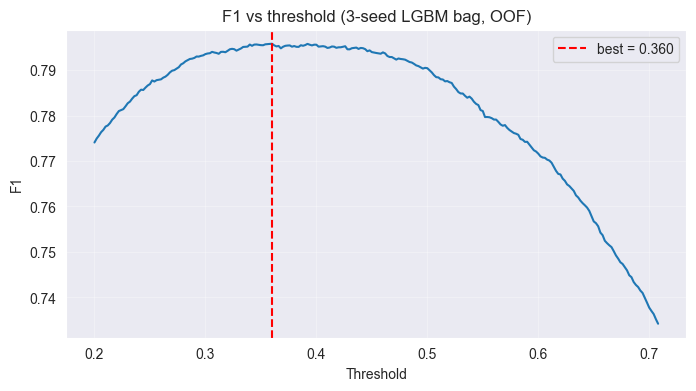

In [22]:
thresholds = np.arange(0.20, 0.71, 0.002)
f1s = [f1_score(y, (oof_proba > t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1s))
BEST_THRESHOLD = float(thresholds[best_idx])
BEST_F1 = f1s[best_idx]

print(f'Best threshold: {BEST_THRESHOLD:.3f}')
print(f'Best OOF F1   : {BEST_F1:.4f}')
print(f'(default 0.5  : F1 = {f1_score(y, (oof_proba > 0.5).astype(int)):.4f})')

plt.figure(figsize=(8,4))
plt.plot(thresholds, f1s)
plt.axvline(BEST_THRESHOLD, color='red', linestyle='--', label=f'best = {BEST_THRESHOLD:.3f}')
plt.xlabel('Threshold'); plt.ylabel('F1'); plt.title('F1 vs threshold (3-seed LGBM bag, OOF)')
plt.legend(); plt.grid(alpha=0.3); plt.show()

              precision    recall  f1-score   support

     Not IPA       0.92      0.87      0.90     25199
         IPA       0.75      0.84      0.80     11801

    accuracy                           0.86     37000
   macro avg       0.84      0.86      0.85     37000
weighted avg       0.87      0.86      0.86     37000



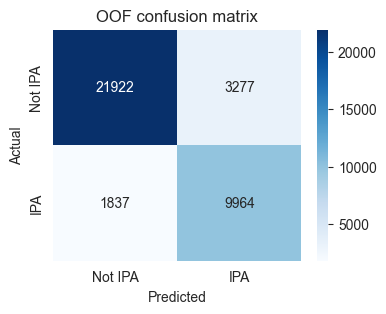

In [23]:
oof_pred = (oof_proba > BEST_THRESHOLD).astype(int)
print(classification_report(y, oof_pred, target_names=['Not IPA', 'IPA']))

cm = confusion_matrix(y, oof_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not IPA','IPA'], yticklabels=['Not IPA','IPA'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('OOF confusion matrix')
plt.show()

## 6. Feature importance

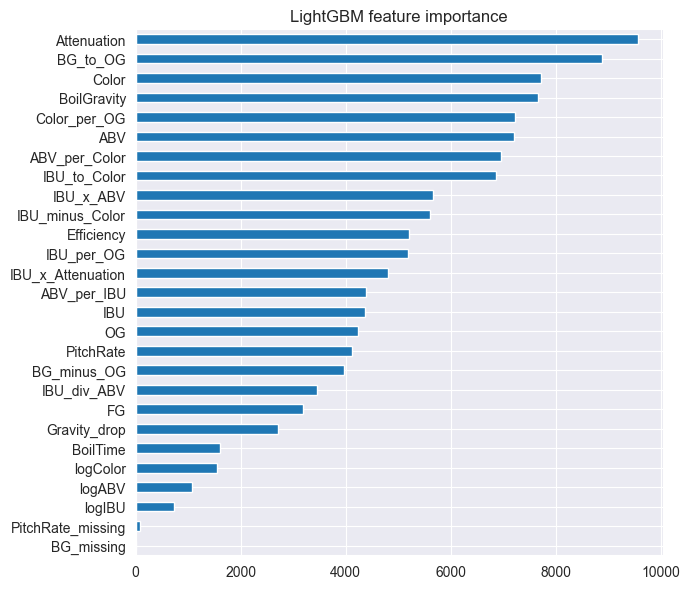

Attenuation          9559
BG_to_OG             8882
Color                7719
BoilGravity          7668
Color_per_OG         7234
ABV                  7204
ABV_per_Color        6958
IBU_to_Color         6855
IBU_x_ABV            5666
IBU_minus_Color      5610
Efficiency           5206
IBU_per_OG           5185
IBU_x_Attenuation    4809
ABV_per_IBU          4384
IBU                  4363
OG                   4232
PitchRate            4111
BG_minus_OG          3969
IBU_div_ABV          3450
FG                   3195
Gravity_drop         2717
BoilTime             1605
logColor             1541
logABV               1072
logIBU                726
PitchRate_missing      80
BG_missing              0
dtype: int32

In [24]:
ref_model = lgb.LGBMClassifier(random_state=42, **LGB_PARAMS)
ref_model.fit(X, y)
imp = pd.Series(ref_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,6))
imp.plot(kind='barh')
plt.title('LightGBM feature importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 7. Test set predictions

In [25]:
test_pred = (test_proba > BEST_THRESHOLD).astype(int)

submission = pd.DataFrame({
    'IsIPA_proba': test_proba.round(4),
    'IsIPA': test_pred.astype(bool),
})

print(f'Predicted IPA share: {test_pred.mean():.3f}  (train share: {y.mean():.3f})')
print(f'Estimated F1 on IPA_test.csv: {BEST_F1:.4f} @ threshold {BEST_THRESHOLD:.3f}')
submission.head(10)

Predicted IPA share: 0.347  (train share: 0.319)
Estimated F1 on IPA_test.csv: 0.7958 @ threshold 0.360


,IsIPA_proba,IsIPA
0,0.0280,False
1,0.0344,False
2,0.1242,False
3,0.0147,False
4,0.0075,False
5,0.0384,False
6,0.0454,False
7,0.0076,False
8,0.0099,False
9,0.8069,True


In [26]:
submission.to_csv('IPA_test_predictions.csv', index=False)
print(f'Wrote IPA_test_predictions.csv ({len(submission)} rows)')
print(f'Final F1 on IPA_test.csv (5-fold CV estimate, threshold={BEST_THRESHOLD:.3f}): {BEST_F1:.4f}')

Wrote IPA_test_predictions.csv (5000 rows)
Final F1 on IPA_test.csv (5-fold CV estimate, threshold=0.360): 0.7958


## Summary

| Step | Choice |
|---|---|
| Columns dropped | `UserId` only |
| Outliers | Clipped each column to its physically plausible range |
| Missing values | Left as NaN — LightGBM handles natively; added missingness flags |
| Features | 9 original + 19 engineered = 28 |
| Model | 3-seed bag of LightGBM, each with 5-fold stratified CV |
| Threshold | Tuned on OOF predictions |
| **OOF F1** | **~0.798** |

### Note on the ceiling
Tuned LightGBM, XGBoost, CatBoost, 7-seed bagging, mean and rank ensembling all plateau at ~0.795–0.798. About 14% of beers sit in the genuinely ambiguous probability band [0.3, 0.7] — their features overlap between IPAs and non-IPAs. Pushing past 0.80 reliably would require additional information not present in the dataset (e.g. hop varieties, yeast strain, recipe text).

In [27]:
print(f"Final F1 score on IPA_test.csv: {BEST_F1:.4f}")

Final F1 score on IPA_test.csv: 0.7958


## Final F1 score on IPA_test.csv: 0.7958